In [1]:
import pandas as pd

df = pd.read_csv("../dataset/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
216,5,109,62,41,129,35.8,0.514,25,1
121,6,111,64,39,0,34.2,0.260,24,0
208,1,96,64,27,87,33.2,0.289,21,0
499,6,154,74,32,193,29.3,0.839,39,0
465,0,124,56,13,105,21.8,0.452,21,0


In [9]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

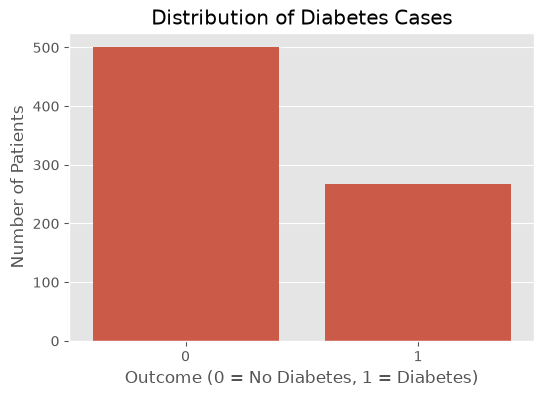

In [10]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
df["Outcome"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df)

plt.title("Distribution of Diabetes Cases")

plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")

plt.ylabel("Number of Patients")

plt.show()

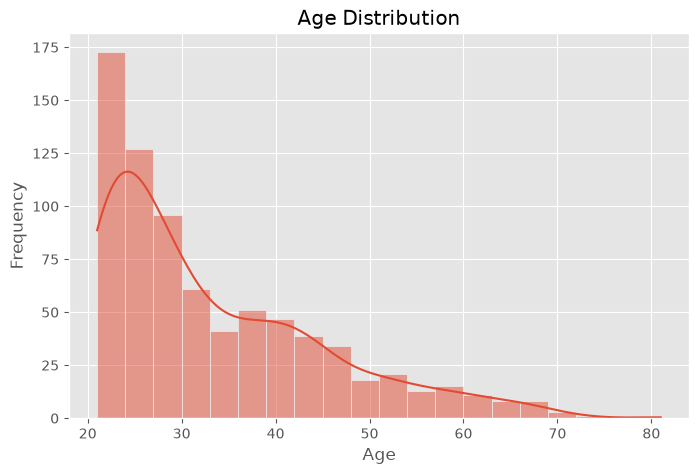

In [11]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

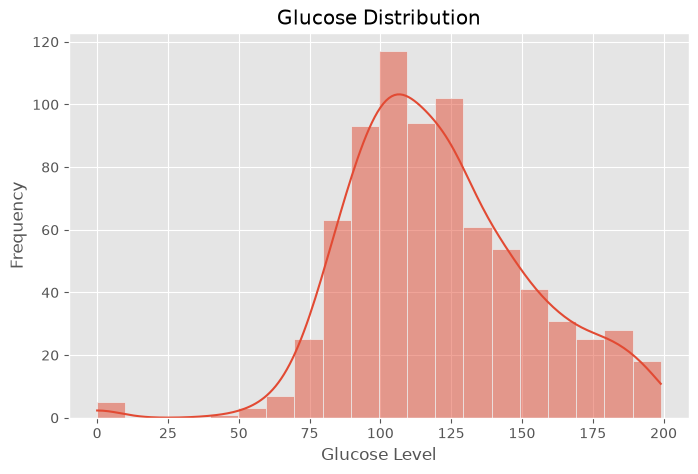

In [12]:
#Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Distribution")

plt.xlabel("Glucose Level")

plt.ylabel("Frequency")

plt.show()

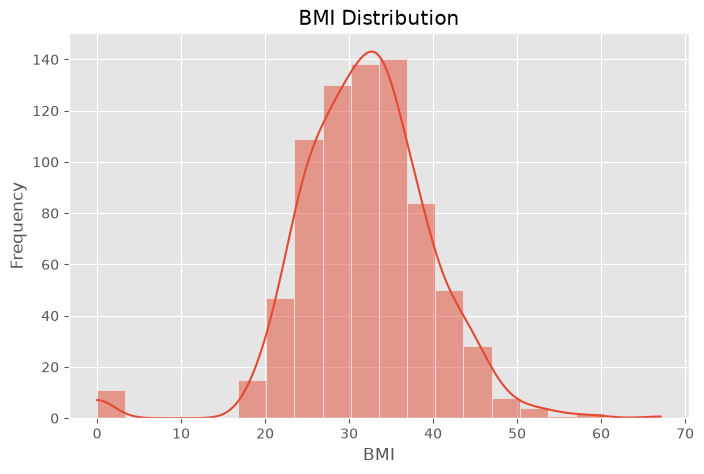

In [13]:
# BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["BMI"], bins=20, kde=True)

plt.title("BMI Distribution")

plt.xlabel("BMI")

plt.ylabel("Frequency")

plt.show()

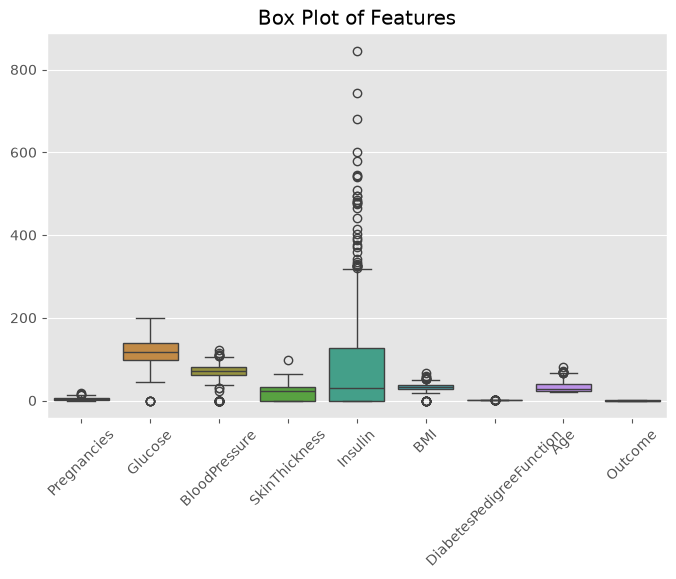

In [14]:
#Detect Outliers
plt.figure(figsize=(8,5))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Box Plot of Features")

plt.show()

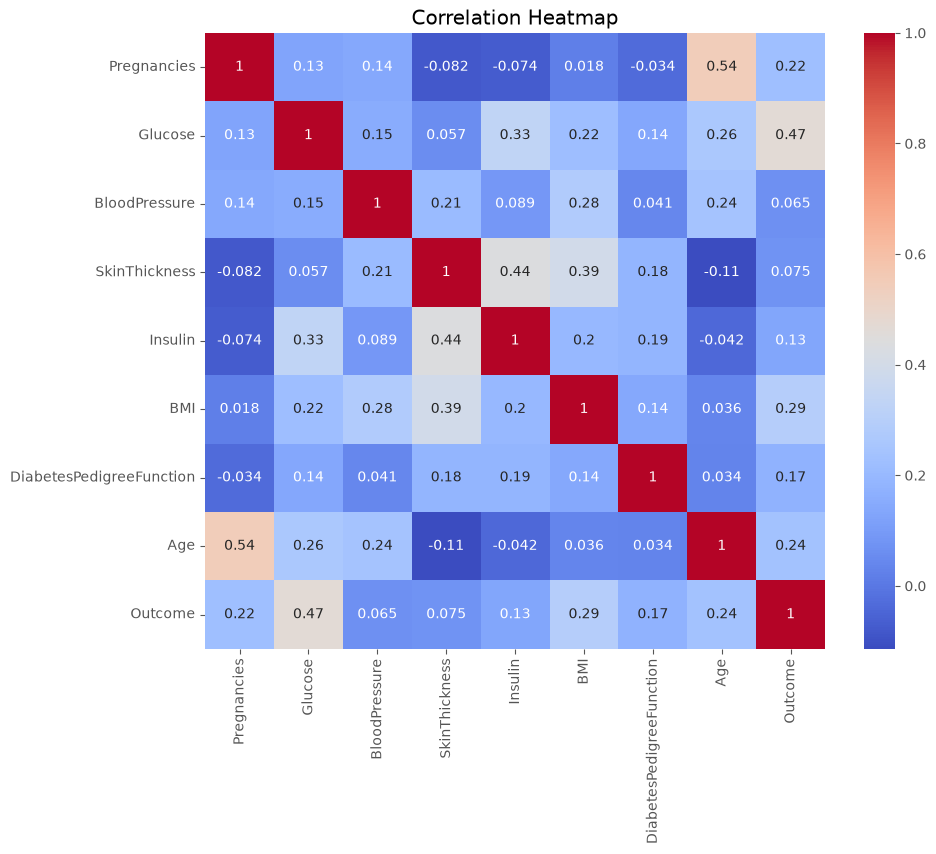

In [15]:
#Correlation Matrix
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

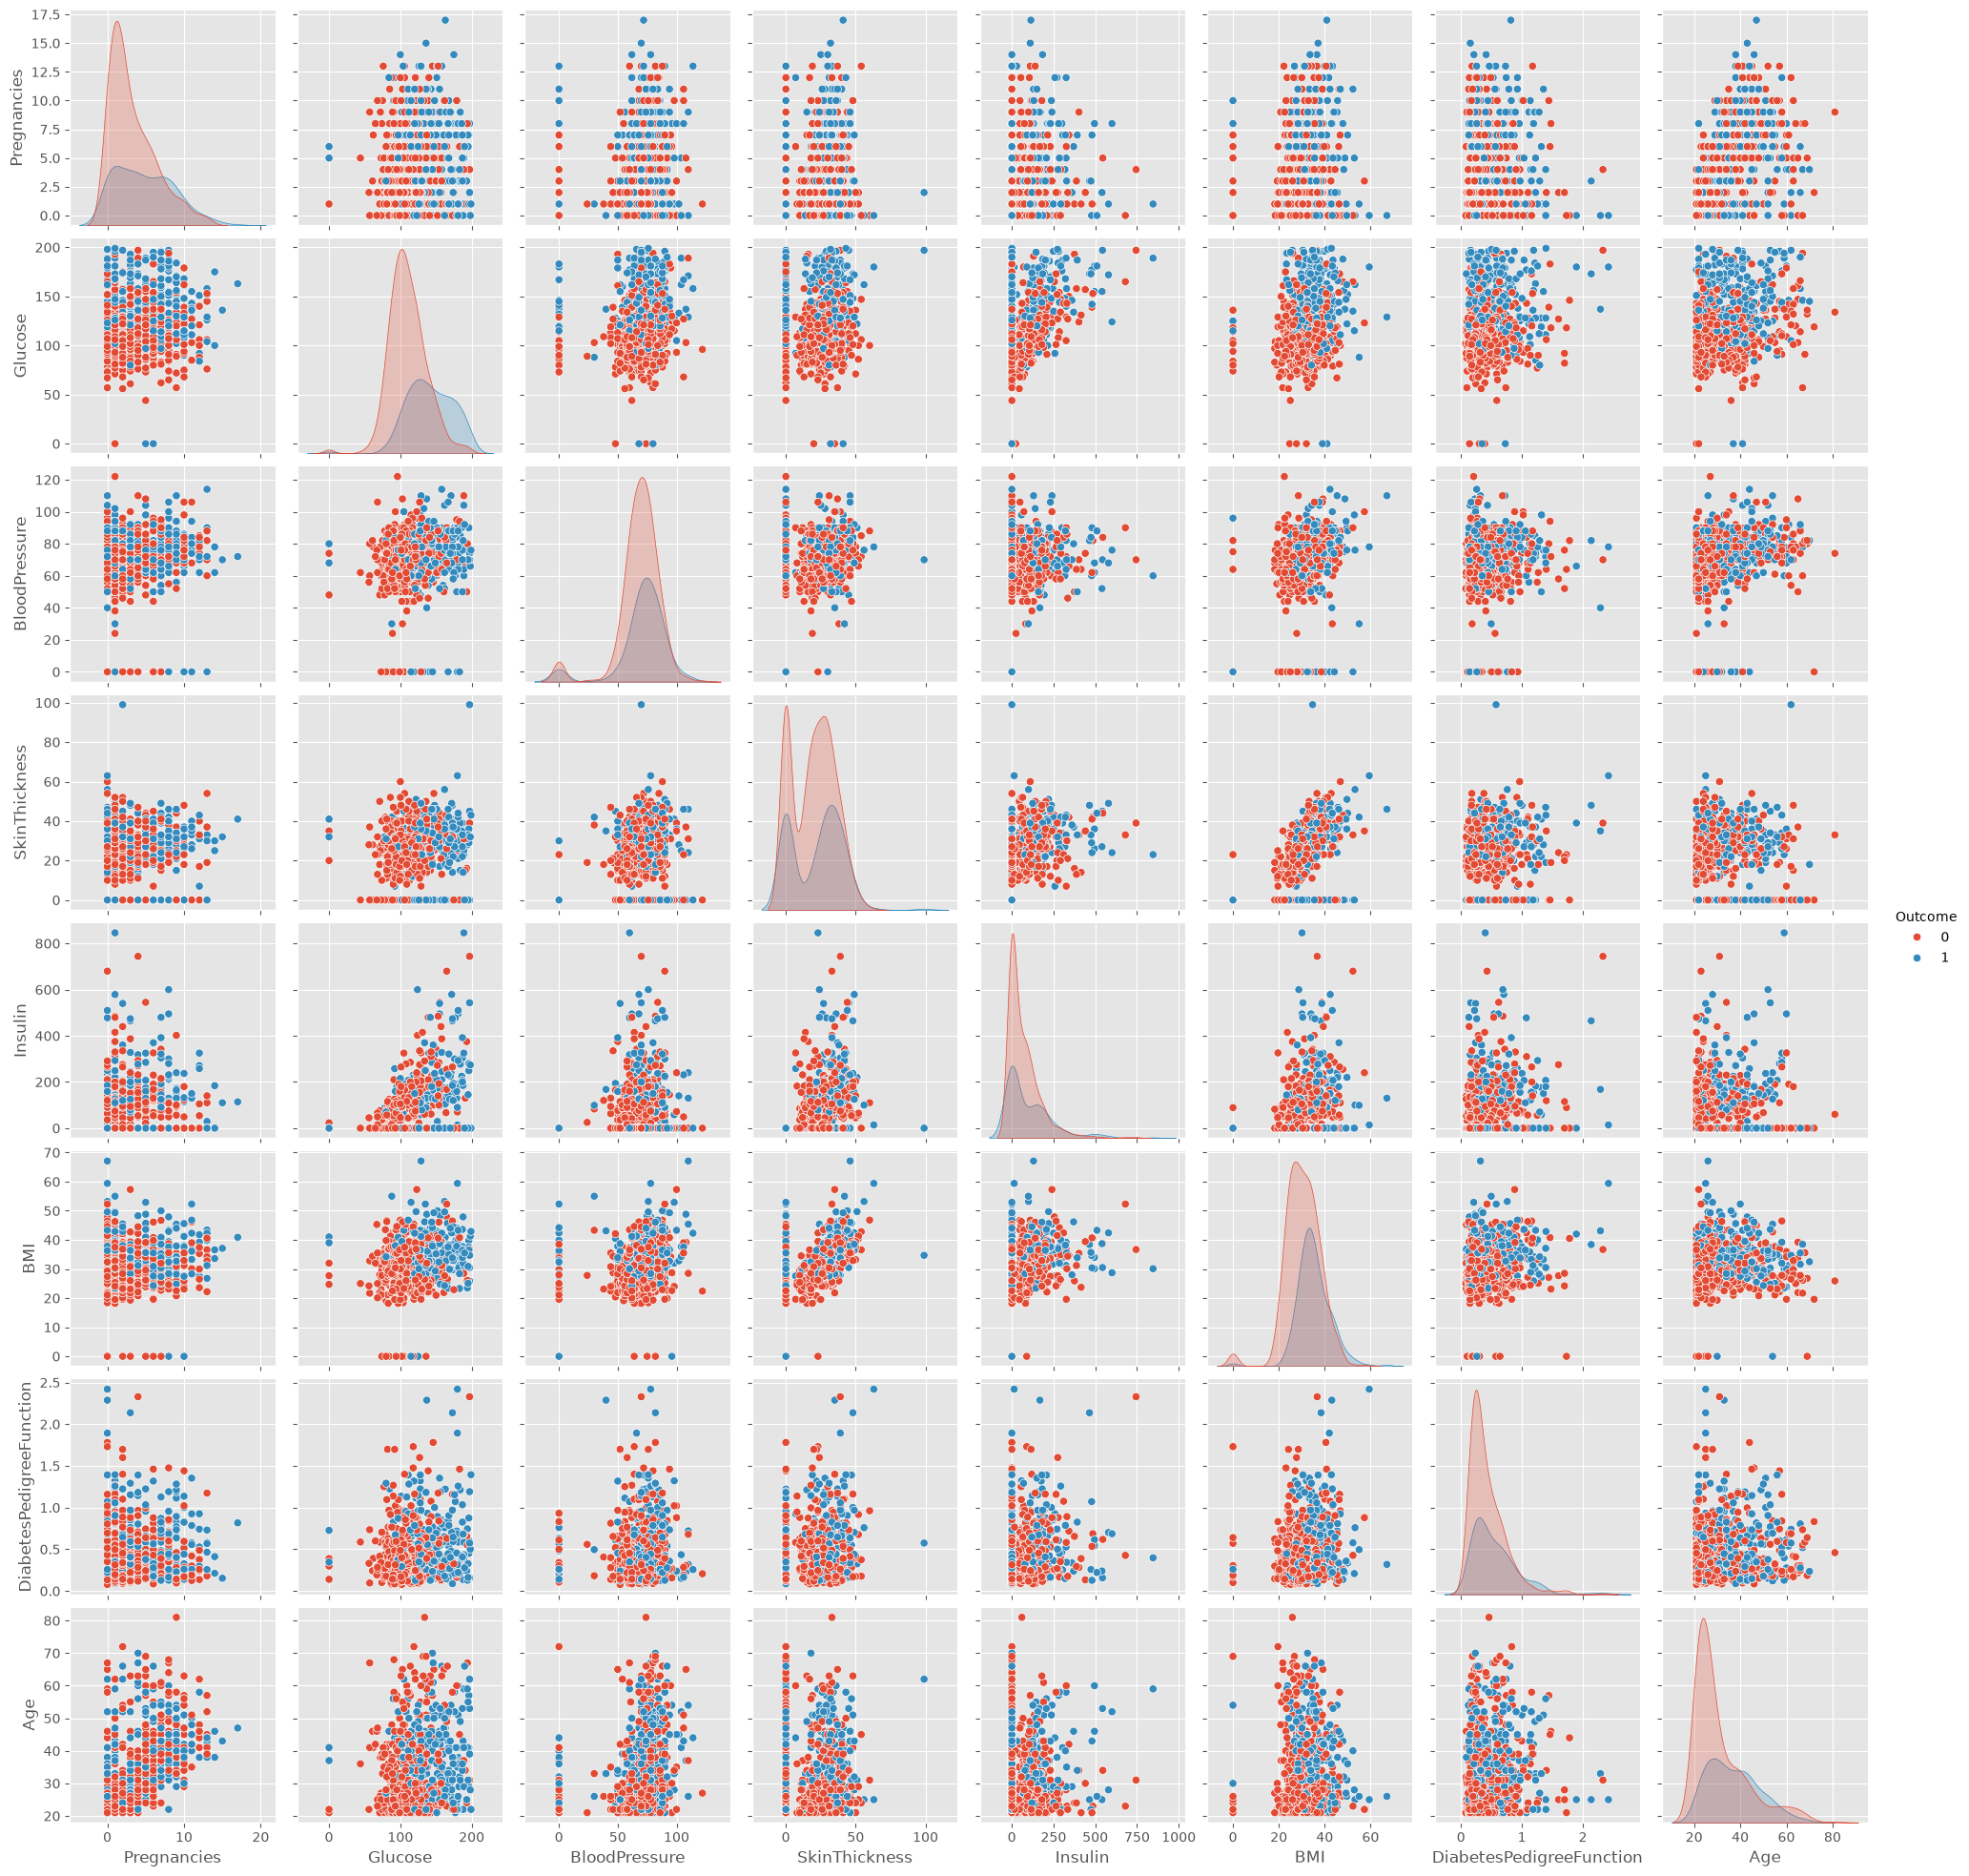

In [16]:
#Pair Plot
sns.pairplot(df, hue="Outcome")

plt.show()

In [17]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]
X.head()
y.head()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])


(614, 8)
(154, 8)
(614,)
(154,)
[[-0.52639686 -1.15139792 -3.75268255 -1.32277365 -0.70120553 -4.13525578
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.27664283  0.68034485  0.23350519 -0.70120553 -0.48916881
   2.41502991  1.48710085]
 [-0.82846011  0.56687102 -1.2658623  -0.09071957  0.01344832 -0.42452187
   0.54916055 -0.94893896]
 [-1.13052335  1.2541786  -1.04961706 -1.32277365 -0.70120553 -1.30372015
  -0.63929127  2.79212217]
 [ 0.68185612  0.41066475  0.57222224  1.07648956  2.48460077  1.83812075
  -0.68682934  1.13909516]]


In [18]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7532467532467533


In [19]:
#Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7337662337662337


In [20]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7207792207792207


In [21]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.6948051948051948


In [22]:
#Compare Models
results = {
    "Logistic Regression": lr_accuracy,
    "Support Vector Machine": svm_accuracy,
    "Random Forest": rf_accuracy,
    "XGBoost": xgb_accuracy
}

print(results)

{'Logistic Regression': 0.7532467532467533, 'Support Vector Machine': 0.7337662337662337, 'Random Forest': 0.7207792207792207, 'XGBoost': 0.6948051948051948}


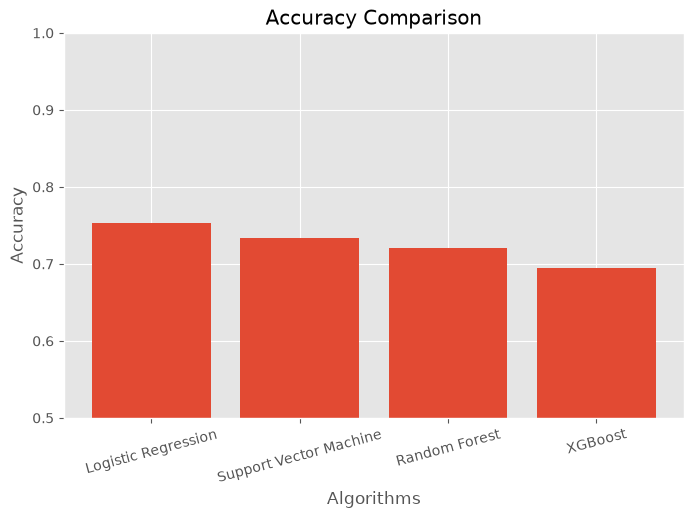

In [23]:
#Plot Accuracy Comparison
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.ylim(0.5,1)

plt.xticks(rotation=15)

plt.show()

In [24]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)


[[77 22]
 [21 34]]


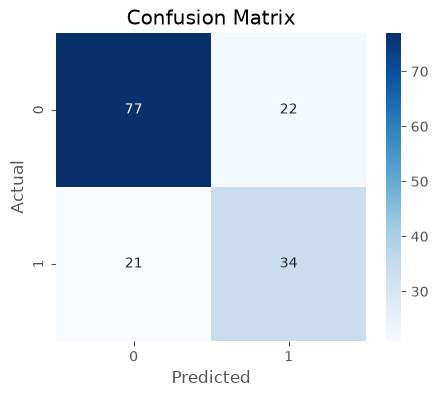

In [25]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [26]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [27]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                    Feature  Importance
1                   Glucose    0.258864
5                       BMI    0.169984
7                       Age    0.140931
6  DiabetesPedigreeFunction    0.123768
2             BloodPressure    0.088134
0               Pregnancies    0.076551
4                   Insulin    0.076122
3             SkinThickness    0.065646


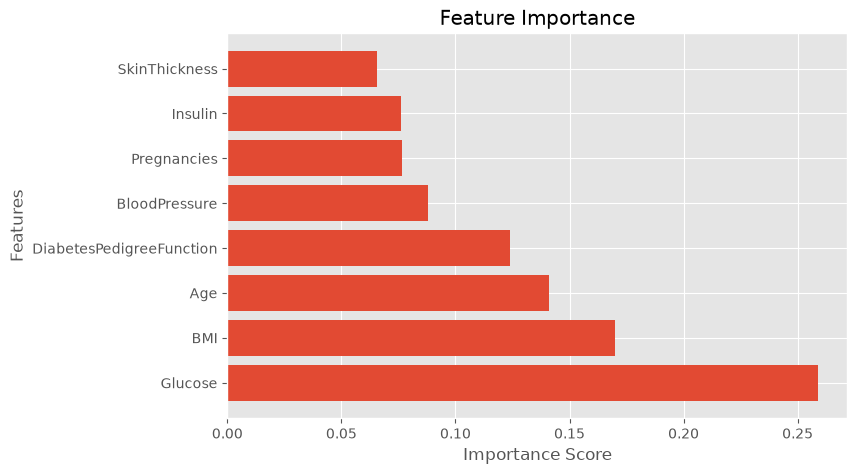

In [28]:
plt.figure(figsize=(8,5))

plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [29]:
import pickle
with open("../model/diabetes_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [30]:
with open("../model/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [31]:
with open("../model/diabetes_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [32]:
with open("../model/scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

In [33]:
import pandas as pd

new_patient = pd.DataFrame(
    [[6,148,72,35,0,33.6,0.627,50]],
    columns=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
)

new_patient_scaled = loaded_scaler.transform(new_patient)

prediction = loaded_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Patient is likely to have Diabetes")
else:
    print("Patient is unlikely to have Diabetes")

Patient is likely to have Diabetes


In [34]:
df.iloc[0]

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                       0.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

In [35]:
patient = pd.DataFrame(
    [[6,148,72,35,0,33.6,0.627,50]],
    columns=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
)

patient_scaled = loaded_scaler.transform(patient)

prediction = loaded_model.predict(patient_scaled)

print("Predicted:", prediction[0])

Predicted: 1


In [36]:
df.iloc[1]

Pregnancies                  1.000
Glucose                     85.000
BloodPressure               66.000
SkinThickness               29.000
Insulin                      0.000
BMI                         26.600
DiabetesPedigreeFunction     0.351
Age                         31.000
Outcome                      0.000
Name: 1, dtype: float64